# GroupX Demo: SelectiveCL Inference and Minimal Training

This notebook is designed for the live demo portion of the DSC3032 final project. It uses the AGD20K-Seen official checkpoint and saves a small number of visual predictions so the demo can finish within two to three minutes.

## Demo Flow

1. Verify the server environment, dataset path, and checkpoint path.
2. Optionally show a minimal training command with only two training steps.
3. Run limited visual inference on AGD20K-Seen.
4. Display original images, ground-truth masks, heatmaps, and overlays.
5. Report the checkpoint evaluation metrics.

In [1]:
#OWN CODE: Define demo paths and imports.
from pathlib import Path
from datetime import datetime
import os
import re
import subprocess
import sys

ROOT = Path('/root/workspace/andycho/CV/SelectiveCL')
DATA_ROOT = Path('/root/workspace/andycho/CV/AGD20K')
CHECKPOINT = ROOT / 'checkpoints' / 'agd20k_seen.pth'
FALLBACK_VISUAL_DIR = ROOT / 'visual_runs' / '20260509_105410' / 'seen_visuals'
DEMO_OUTPUT_DIR = ROOT / 'demo_runs' / 'groupx_seen_visuals'

os.chdir(ROOT)
print('Working directory:', Path.cwd())

Working directory: /root/workspace/andycho/CV/SelectiveCL


In [2]:
#OWN CODE: Verify environment, data, and checkpoint availability.
print('Python executable:', sys.executable)
print('Python version:', sys.version.split()[0])

try:
    import torch
    print('Torch version:', torch.__version__)
    print('CUDA available:', torch.cuda.is_available())
    print('CUDA device count:', torch.cuda.device_count())
except Exception as exc:
    print('Torch import failed:', repr(exc))

required_paths = {
    'AGD20K-Seen test images': DATA_ROOT / 'Seen/testset/egocentric',
    'AGD20K-Seen GT masks': DATA_ROOT / 'Seen/testset/GT',
    'AGD20K-Seen checkpoint': CHECKPOINT,
}

for label, path in required_paths.items():
    print(f'{label}: {path} -> {Path(path).exists()}')

Python executable: /root/anaconda3/envs/selectivecl/bin/python
Python version: 3.7.16


Torch version: 1.9.0
CUDA available: True
CUDA device count: 4
AGD20K-Seen test images: /root/workspace/andycho/CV/AGD20K/Seen/testset/egocentric -> True
AGD20K-Seen GT masks: /root/workspace/andycho/CV/AGD20K/Seen/testset/GT -> True
AGD20K-Seen checkpoint: /root/workspace/andycho/CV/SelectiveCL/checkpoints/agd20k_seen.pth -> True


/root/anaconda3/envs/selectivecl/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Minimal Training Cell

The following cell documents a minimal training run. It is disabled by default for live presentation stability. If the instructor asks to see training execute, set `RUN_MINIMAL_TRAINING = True`.

In [3]:
#OWN CODE: Minimal training is guarded to keep the live demo under three minutes.
RUN_MINIMAL_TRAINING = False

if RUN_MINIMAL_TRAINING:
    command = [
        sys.executable, 'train.py',
        '--data_root', str(DATA_ROOT),
        '--save_root', 'demo_smoke_models',
        '--divide', 'Seen',
        '--epochs', '1',
        '--batch_size', '1',
        '--num_workers', '0',
        '--test_batch_size', '1',
        '--test_num_workers', '0',
        '--max_train_steps', '2',
        '--max_test_steps', '2',
        '--show_step', '1',
        '--gpu', '0',
    ]
    print('Running:', ' '.join(command))
    subprocess.run(command, check=True)
else:
    smoke_log = ROOT / 'smoke_models' / '20260507_151200' / 'run.log'
    print('Minimal training is disabled for the live demo.')
    print('Existing smoke-test log:', smoke_log)
    if smoke_log.exists():
        print('\n'.join(smoke_log.read_text().splitlines()[-12:]))

Minimal training is disabled for the live demo.
Existing smoke-test log: /root/workspace/andycho/CV/SelectiveCL/smoke_models/20260507_151200/run.log
mask_root=/root/workspace/andycho/CV/AGD20K/Seen/testset/GT
save_path=smoke_models/20260507_151200

Loading pretrained ViT-B-16 from OpenAI.
LR = [0.001, 0.002, 0.01, 0.02]
1/1]1/20061 Ac(gx): 0.00/0.00 Lce(gx): 3.88/3.88 Lpctl: 13.99 Lctlpx: 37.79
1/1]2/20061 Ac(gx): 0.00/0.00 Lce(gx): 3.63/3.63 Lpctl: 13.95 Lctlpx: 37.64
Reached max_train_steps=2
Reached max_test_steps=2
epoch|mKLD|mSIM|mNSS , 1, 2.02, 0.19, 0.286,   BEST epoch|mKLD|mSIM|mNSS , 1, 1000, 0, 0
refined ego-ego + mKLD|mSIM|mNSS = 2.125, 0.175, -0.037, BEST e|mKLD|mSIM|mNSS , 1, 1000, 0, 0
refined ego-mean + mKLD|mSIM|mNSS = 2.068, 0.175, -0.061, BEST e|mKLD|mSIM|mNSS , 1, 1000, 0, 0


## Limited Visual Inference

This cell evaluates the official AGD20K-Seen checkpoint and saves only five visual examples. If GPU time is unavailable during the live demo, set `RUN_VISUAL_INFERENCE = False` and use the existing fallback visual results.

In [4]:
#OWN CODE: Run a short visual inference pass with the official AGD20K-Seen checkpoint.
RUN_VISUAL_INFERENCE = True

if RUN_VISUAL_INFERENCE:
    DEMO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    command = [
        sys.executable, 'test.py',
        '--data_root', str(DATA_ROOT),
        '--model_file', str(CHECKPOINT),
        '--divide', 'Seen',
        '--gpu', '0',
        '--test_batch_size', '1',
        '--test_num_workers', '0',
        '--save_visuals',
        '--save_heatmaps',
        '--max_save_images', '5',
        '--save_path', str(DEMO_OUTPUT_DIR),
    ]
    print('Running:', ' '.join(command))
    subprocess.run(command, check=True)
else:
    print('Visual inference is skipped. The notebook will use fallback visual outputs if available.')

Running: /root/anaconda3/envs/selectivecl/bin/python test.py --data_root /root/workspace/andycho/CV/AGD20K --model_file /root/workspace/andycho/CV/SelectiveCL/checkpoints/agd20k_seen.pth --divide Seen --gpu 0 --test_batch_size 1 --test_num_workers 0 --save_visuals --save_heatmaps --max_save_images 5 --save_path /root/workspace/andycho/CV/SelectiveCL/demo_runs/groupx_seen_visuals


  0%|          | 0/1675 [00:00<?, ?it/s]

  0%|          | 1/1675 [00:01<34:57,  1.25s/it]

  0%|          | 2/1675 [00:01<20:38,  1.35it/s]

  0%|          | 3/1675 [00:02<17:29,  1.59it/s]

...

100%|█████████▉| 1668/1675 [03:52<00:01,  6.20it/s]

100%|█████████▉| 1670/1675 [03:52<00:00,  7.17it/s]

100%|█████████▉| 1673/1675 [03:53<00:00,  8.81it/s]

100%|██████████| 1675/1675 [03:53<00:00,  7.17it/s]


KLD, SIM, NSS, 1.142, 0.415, 1.303
reeKLD, reeSIM, reeNSS, 1.124, 0.433, 1.28
remKLD, remSIM, remNSS, 1.14, 0.422, 1.283


In [5]:
#OWN CODE: Select demo visuals from the current run or from existing saved outputs.
def choose_visual_dir():
    if (DEMO_OUTPUT_DIR / 'overlay').exists() and list((DEMO_OUTPUT_DIR / 'overlay').glob('*.png')):
        return DEMO_OUTPUT_DIR
    if (FALLBACK_VISUAL_DIR / 'overlay').exists() and list((FALLBACK_VISUAL_DIR / 'overlay').glob('*.png')):
        return FALLBACK_VISUAL_DIR
    raise FileNotFoundError('No visual outputs are available. Run the visual inference cell first.')

VISUAL_DIR = choose_visual_dir()
print('Using visual directory:', VISUAL_DIR)

Using visual directory: /root/workspace/andycho/CV/SelectiveCL/demo_runs/groupx_seen_visuals


In [6]:
#OWN CODE: Build a lookup that maps saved visualization filenames back to original images and GT masks.
from PIL import Image
from IPython.display import display

TEST_IMAGE_ROOT = DATA_ROOT / 'Seen/testset/egocentric'
MASK_ROOT = DATA_ROOT / 'Seen/testset/GT'
PREDICTION_SUFFIXES = ['ego_pred', 'refined_ego', 'refined_mean']

def find_image_for_mask(mask_path):
    relative_stem = mask_path.relative_to(MASK_ROOT).with_suffix('')
    for extension in ['.jpg', '.jpeg', '.png']:
        candidate = TEST_IMAGE_ROOT / relative_stem.with_suffix(extension)
        if candidate.exists():
            return candidate
    return None

def build_visual_lookup():
    lookup = {}
    for mask_path in MASK_ROOT.rglob('*.png'):
        stem = '_'.join(mask_path.relative_to(MASK_ROOT).with_suffix('').parts)
        image_path = find_image_for_mask(mask_path)
        if image_path is None:
            continue
        for suffix in PREDICTION_SUFFIXES:
            lookup[f'{stem}_{suffix}.png'] = {'image': image_path, 'mask': mask_path, 'prediction': suffix}
    return lookup

visual_lookup = build_visual_lookup()
print('Lookup entries:', len(visual_lookup))

Lookup entries: 5025


pour_bottle_bottle_001115_refined_ego.png


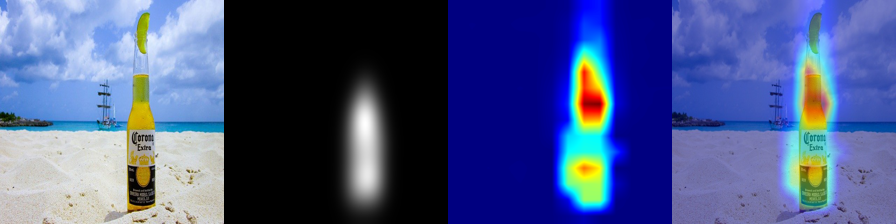

Panel order: original image | ground-truth mask | predicted heatmap | overlay
pour_bottle_bottle_001167_refined_ego.png


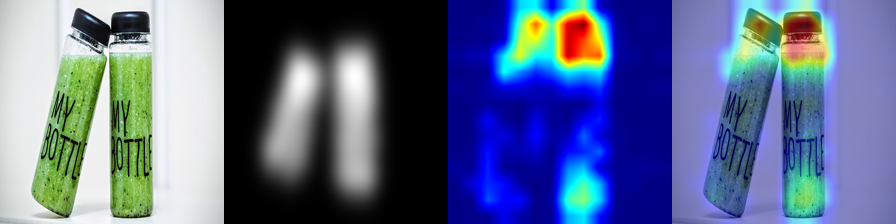

Panel order: original image | ground-truth mask | predicted heatmap | overlay
pour_bottle_bottle_001227_refined_ego.png


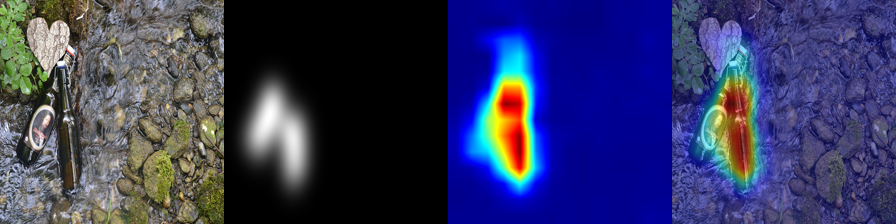

Panel order: original image | ground-truth mask | predicted heatmap | overlay
pour_bottle_bottle_002103_refined_ego.png


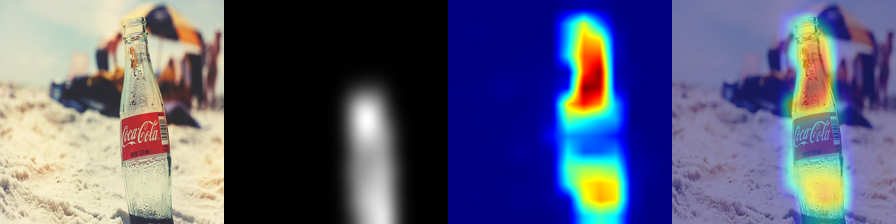

Panel order: original image | ground-truth mask | predicted heatmap | overlay
pour_bottle_bottle_002805_refined_ego.png


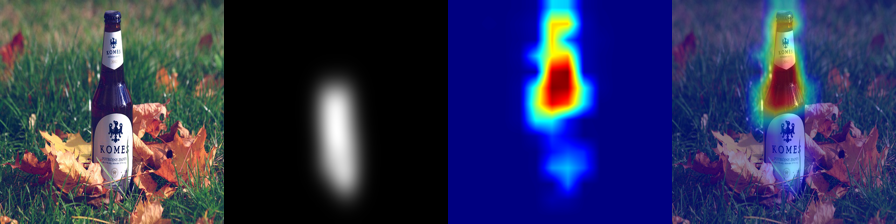

Panel order: original image | ground-truth mask | predicted heatmap | overlay


In [7]:
#OWN CODE: Display original images, GT masks, heatmaps, and overlays for five refined predictions.
def resize_for_display(image, size=(224, 224)):
    return image.convert('RGB').resize(size)

def make_panel(image_path, mask_path, heatmap_path, overlay_path):
    images = [
        resize_for_display(Image.open(image_path)),
        resize_for_display(Image.open(mask_path)),
        resize_for_display(Image.open(heatmap_path)),
        resize_for_display(Image.open(overlay_path)),
    ]
    width, height = images[0].size
    panel = Image.new('RGB', (width * len(images), height), color='white')
    for index, image in enumerate(images):
        panel.paste(image, (index * width, 0))
    return panel

overlay_files = sorted((VISUAL_DIR / 'overlay').glob('*_refined_ego.png'))[:5]
for overlay_path in overlay_files:
    item = visual_lookup.get(overlay_path.name)
    if item is None:
        print('Skipping unmatched visualization:', overlay_path.name)
        continue
    heatmap_path = VISUAL_DIR / 'heatmap' / overlay_path.name
    print(overlay_path.name)
    display(make_panel(item['image'], item['mask'], heatmap_path, overlay_path))
    print('Panel order: original image | ground-truth mask | predicted heatmap | overlay')

In [8]:
#OWN CODE: Show the official checkpoint metric values used in the presentation.
metric_log = ROOT / 'full_runs' / '20260508_023621' / 'test_seen_official.log'
if metric_log.exists():
    print(metric_log.read_text())
else:
    print('Expected metric log is missing:', metric_log)

[2026-05-08 11:01:29] Command: python test.py --data_root /root/workspace/andycho/CV/AGD20K --model_file /root/workspace/andycho/CV/SelectiveCL/checkpoints/agd20k_seen.pth --divide Seen --gpu 0

100%|██████████| 1675/1675 [02:01<00:00, 13.82it/s]
KLD, SIM, NSS, 1.142, 0.415, 1.303
reeKLD, reeSIM, reeNSS, 1.124, 0.433, 1.28
remKLD, remSIM, remNSS, 1.14, 0.422, 1.283



## Live Demo Script

Use the following short English script during the demo:

1. This notebook loads the AGD20K-Seen official checkpoint for SelectiveCL.
2. Full training is not run live because the completed 15-epoch run takes several hours.
3. The minimal training cell shows that the training loop works with two training steps and two evaluation steps.
4. The inference cell saves five predictions and visualizes each sample as original image, ground-truth mask, predicted heatmap, and overlay.
5. The official checkpoint reproduces the paper result on AGD20K-Seen: KLD 1.124, SIM 0.433, NSS 1.280.